In [97]:
import pandas as pd
import numpy as np
import cvxpy as cp
from scipy.stats import linregress
import matplotlib.pyplot as plt

### Generate Synthetic Data

In [98]:
# 1. SETUP
naics_codes = [11, 21, 22, 23, 31, 42, 44, 48, 51, 52, 53, 54, 55, 56, 61, 62, 71, 72, 81, 90]
years = np.arange(2006, 2027)
n_industries = len(naics_codes)

# 2. GENERATE TIME SERIES DATA
ts_data = []

for code in naics_codes:
    # Starting jobs and a unique growth 'personality' for each industry
    base_jobs = np.random.randint(500000, 5000000)
    growth_drift = np.random.uniform(-0.02, 0.05)
    volatility = np.random.uniform(0.01, 0.04)
    
    # Real-world Multiplier parameters (Hidden from the optimizer)
    true_alpha = np.random.uniform(1.5, 3.0)
    true_beta = np.random.uniform(0.7, 0.9)
    
    current_jobs = base_jobs
    for year in years:
        # Simulate annual job changes
        change = np.random.normal(growth_drift, volatility)
        current_jobs = int(current_jobs * (1 + change))
        
        # Simulate the 'Observed' Multiplier (Impact / Jobs)
        # Note: As jobs grow, the multiplier naturally 'drifts' down due to beta
        observed_impact = true_alpha * (current_jobs ** true_beta)
        observed_multiplier = observed_impact / current_jobs
        
        ts_data.append({
            'Year': year,
            'NAICS': code,
            'Jobs': current_jobs,
            'Total_Impact': observed_impact,
            'Observed_Multiplier': observed_multiplier
        })

df_ts = pd.DataFrame(ts_data)

# 3. SAVE TO EXCEL
with pd.ExcelWriter('Regional_Long_Term_Data.xlsx') as writer:
    df_ts.to_excel(writer, sheet_name='Time_Series', index=False)
    # (Optional: Add SAM or Shift-Share sheets here as well)

print("20-Year Time Series generated in 'Regional_Long_Term_Data.xlsx'")

20-Year Time Series generated in 'Regional_Long_Term_Data.xlsx'


In [99]:
# 1. LOAD AND ESTIMATE PARAMETERS
df = pd.read_excel('Regional_Long_Term_Data.xlsx', sheet_name='Time_Series')
naics_list = df['NAICS'].unique()

params = []
industry_returns = []

for code in naics_list:
    sub = df[df['NAICS'] == code].sort_values('Year')
    
    # Estimate Alpha and Beta via Log-Log Regression: ln(Impact) = ln(Alpha) + Beta*ln(Jobs)
    # This is how you 'find' the diminishing returns in real data
    slope, intercept, r_val, p_val, std_err = linregress(np.log(sub['Jobs']), np.log(sub['Total_Impact']))
    
    params.append({
        'NAICS': code,
        'Alpha': np.exp(intercept),
        'Beta': slope, # This is your diminishing returns coefficient
        'Current_Jobs': sub['Jobs'].iloc[-1]
    })
    
    # Capture annual % change for Covariance (Risk)
    industry_returns.append(sub['Jobs'].pct_change().dropna().values)

results_df = pd.DataFrame(params)
sigma = np.cov(np.array(industry_returns)) # The Risk Matrix

# 2. OPTIMIZATION
n = len(naics_list)
x = cp.Variable(n, nonneg=True)
alphas = results_df['Alpha'].values
betas = results_df['Beta'].values
current_total_jobs = results_df['Current_Jobs'].sum()
q = 0.1 # Risk Aversion

scale = 1e6
current_jobs_vec = results_df['Current_Jobs'].values / scale
total_target = current_total_jobs / scale

# Objective: Maximize Impact - q * Risk
scaled_alphas = alphas * (scale**betas) / scale
impact_terms = [scaled_alphas[i] * cp.power(x[i], betas[i]) for i in range(n)]
impact = cp.sum(impact_terms)
risk = q * cp.quad_form(x / current_total_jobs, sigma) 
objective = cp.Maximize(impact - risk)

# Constraints
lower_bound = 0.1
upper_bound = 3.0
constraints = [
    cp.sum(x) == total_target,
    x >= current_jobs_vec * lower_bound,
    x <= current_jobs_vec * upper_bound
]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS, eps=1e-5)

lower_bound = 0.1
upper_bound = 3.0
lower_bound_sum = (results_df['Current_Jobs'] * lower_bound).sum()
upper_bound_sum = (results_df['Current_Jobs'] * upper_bound).sum()
target = current_total_jobs

print(f"Total Jobs to allocate: {target:,}")
print(f"Minimum required by constraints: {lower_bound_sum:,}")
print(f"Maximum allowed by constraints: {upper_bound_sum:,}")

if not (lower_bound_sum <= target <= upper_bound_sum):
    print("ERROR: Your bounds make the problem impossible!")

# 3. OUTPUT
if prob.status not in ["optimal", "optimal_inaccurate"]:
    print(f"Solver failed! Status: {prob.status}")
    # Create dummy values so the print doesn't crash
    results_df['Optimal_Jobs'] = np.nan
    results_df['Shift_Needed'] = np.nan
elif prob.status in ["optimal", "optimal_inaccurate"]:
    results_df['Optimal_Jobs'] = x.value * scale
    results_df['Shift_Needed'] = results_df['Optimal_Jobs'] - results_df['Current_Jobs']
    print(f"Optimization Successful. Status: {prob.status}")

print("\n--- RESULTS ---")
print(results_df[['NAICS', 'Beta', 'Current_Jobs', 'Optimal_Jobs', 'Shift_Needed']].round(2))
#print(f"Risk: {risk}")

Total Jobs to allocate: 92,484,317
Minimum required by constraints: 9,248,431.700000001
Maximum allowed by constraints: 277,452,951.0
Optimization Successful. Status: optimal

--- RESULTS ---
    NAICS  Beta  Current_Jobs  Optimal_Jobs  Shift_Needed
0      11  0.87       1064106    3192314.47    2128208.47
1      21  0.88       2975377    8926168.47    5950791.47
2      22  0.76       5957772     595728.37   -5362043.63
3      23  0.75        830872      83097.77    -747774.23
4      31  0.89       4889143   14667324.04    9778181.04
5      42  0.77       3181251     318113.56   -2863137.44
6      44  0.73      10599955    1060354.98   -9539600.02
7      48  0.82       2371556     303227.82   -2068328.18
8      51  0.82       5936384     593621.21   -5342762.79
9      52  0.80       5171863     537671.41   -4634191.59
10     53  0.85       5678279   13520515.49    7842236.49
11     54  0.77       1872462     187249.59   -1685212.41
12     55  0.89       2276064    6828212.01    4552148

In [100]:
# Calculate Marginal Multipliers
# Multiplier = Alpha * Beta * (Jobs ^ (Beta - 1))

# Current Multipliers
results_df['Current_Multiplier'] = (
    results_df['Alpha'] * results_df['Beta'] * (results_df['Current_Jobs'] ** (results_df['Beta'] - 1))
)

# Optimal Multipliers
results_df['Optimal_Multiplier'] = (
    results_df['Alpha'] * results_df['Beta'] * (results_df['Optimal_Jobs'] ** (results_df['Beta'] - 1))
)

# Calculate Regional Averages
avg_current_m = results_df['Current_Multiplier'].mean()
avg_optimal_m = results_df['Optimal_Multiplier'].mean()
percent_change_in_m = (avg_optimal_m - avg_current_m) / avg_current_m

display(results_df)
print(f"Average Regional Multiplier (Current): {avg_current_m:.4f}")
print(f"Average Regional Multiplier (Optimal): {avg_optimal_m:.4f}")
print(f"Percent Change from Current to Optimal: {100 * percent_change_in_m:.4f}%")

,NAICS,Alpha,Beta,Current_Jobs,Optimal_Jobs,Shift_Needed,Current_Multiplier,Optimal_Multiplier
0,11,1.751467,0.869735,1064106,3.192314e+06,2.128208e+06,0.249851,0.216536
1,21,2.906589,0.884911,2975377,8.926168e+06,5.950791e+06,0.462648,0.407698
2,22,2.166286,0.759269,5957772,5.957284e+05,-5.362044e+06,0.038471,0.066969
3,23,1.969645,0.750404,830872,8.309777e+04,-7.477742e+05,0.049225,0.087452
4,31,2.519290,0.893255,4889143,1.466732e+07,9.778181e+06,0.434721,0.386617
5,42,2.121655,0.765141,3181251,3.181136e+05,-2.863137e+06,0.048220,0.082811
6,44,2.183423,0.734980,10599955,1.060355e+06,-9.539600e+06,0.022058,0.040602
7,48,1.896104,0.815186,2371556,3.032278e+05,-2.068328e+06,0.102548,0.149973
8,51,1.659477,0.815311,5936384,5.936212e+05,-5.342763e+06,0.075910,0.116142
9,52,2.566569,0.801541,5171863,5.376714e+05,-4.634192e+06,0.095696,0.149971


Average Regional Multiplier (Current): 0.1621
Average Regional Multiplier (Optimal): 0.1725
Percent Change from Current to Optimal: 6.3862%


In [101]:
total_job_shift_needed = results_df["Shift_Needed"].abs().sum()
percent_total_shift_needed = total_job_shift_needed / current_total_jobs 
print("Current total jobs:\n", current_total_jobs)
print("\nTotal job shift needed:\n", total_job_shift_needed)
print("\nTotal job shift needed as a percent of total current jobs:\n", percent_total_shift_needed)

Current total jobs:
 92484317

Total job shift needed:
 112448980.2039562

Total job shift needed as a percent of total current jobs:
 1.2158707968179752


In [102]:
results_df['At_Ceiling'] = results_df['Optimal_Jobs'] == (results_df['Current_Jobs'] * upper_bound)
results_df['At_Floor'] = results_df['Optimal_Jobs'] == (results_df['Current_Jobs'] * lower_bound)
print(results_df[['NAICS', 'At_Ceiling', 'At_Floor']])

    NAICS  At_Ceiling  At_Floor
0      11       False     False
1      21       False     False
2      22       False     False
3      23       False     False
4      31       False     False
5      42       False     False
6      44       False     False
7      48       False     False
8      51       False     False
9      52       False     False
10     53       False     False
11     54       False     False
12     55       False     False
13     56       False     False
14     61       False     False
15     62       False     False
16     71       False     False
17     72       False     False
18     81       False     False
19     90       False     False


In [103]:
# Print the values of the two parts of your objective
print(f"Total Impact: {impact.value}")
print(f"Total Risk Component: {risk.value}")

Total Impact: 29.864689265014157
Total Risk Component: 1.2900615720760097e-17


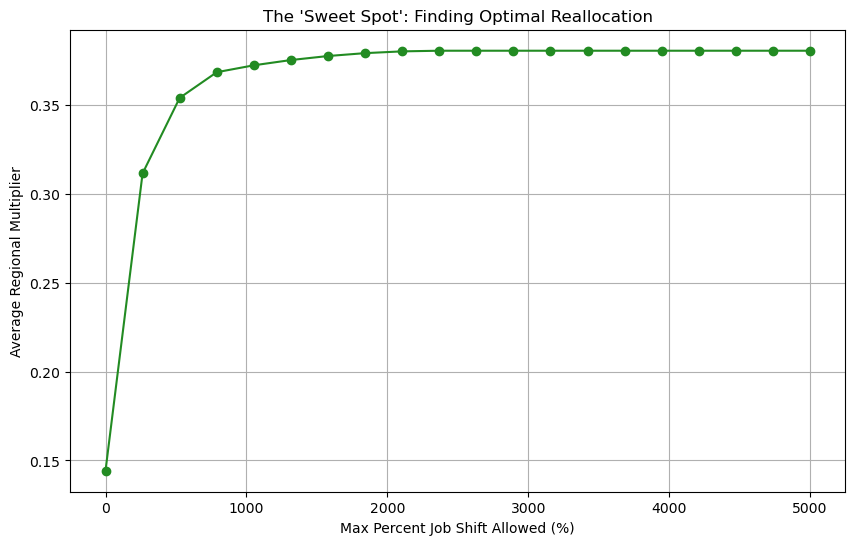

In [105]:

shift_levels = np.linspace(0, 50, 20) # Test shifts from 0% to 50%
multiplier_results = []

for s in shift_levels:
    x_sweep = cp.Variable(n, nonneg=True)
    
    # Impact and Risk (using your existing logic)
    impact_sweep = cp.sum([scaled_alphas[i] * cp.power(x_sweep[i], betas[i]) for i in range(n)])
    # We'll set q=0.5 for a balanced look
    obj_sweep = cp.Maximize(impact_sweep - 0.5 * cp.quad_form(x_sweep / total_target, sigma))
    
    constraints_sweep = [
        cp.sum(x_sweep) == total_target,
        x_sweep >= current_jobs_vec * (1 - s),
        x_sweep <= current_jobs_vec * (1 + s)
    ]
    
    prob_sweep = cp.Problem(obj_sweep, constraints_sweep)
    prob_sweep.solve(solver=cp.SCS)
    
    if prob_sweep.status in ["optimal", "optimal_inaccurate"]:
        # Calculate resulting weighted average multiplier
        opt_m = (alphas * betas * ((x_sweep.value * scale)**(betas - 1)))
        weighted_m = (opt_m * (x_sweep.value * scale)).sum() / current_total_jobs
        multiplier_results.append(weighted_m)
    else:
        multiplier_results.append(None)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(shift_levels * 100, multiplier_results, marker='o', color='forestgreen')
plt.title("The 'Sweet Spot': Finding Optimal Reallocation")
plt.xlabel("Max Percent Job Shift Allowed (%)")
plt.ylabel("Average Regional Multiplier")
plt.grid(True)
plt.show()